In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sqlalchemy import create_engine

In [2]:
profit_loss = pd.read_csv(
    "exports/clean_profit_loss.csv"
)

profit_loss.head()

,id,company_id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,profit_before_tax,tax_percentage,net_profit,eps,dividend_payout,net_margin,operating_margin,interest_burden
0,61,ABB,Dec 2012,1653,1451,202.0,12.0,33,0,19,215,33.0,145,68.0,25.0,8.771930,12.220206,0.000000
1,62,ABB,Mar 2014,2276,2009,267.0,12.0,49,0,22,295,33.0,198,93.0,25.0,8.699473,11.731107,0.000000
2,63,ABB,Mar 2015,2289,1977,312.0,14.0,48,0,15,344,34.0,229,108.0,29.0,10.004369,13.630406,0.000000
3,64,ABB,Mar 2016,2614,2250,365.0,14.0,50,3,14,398,36.0,255,120.0,29.0,9.755164,13.963275,0.114767
4,65,ABB,Mar 2017,2903,2505,398.0,14.0,57,2,16,436,37.0,277,130.0,31.0,9.541853,13.709955,0.068894


In [3]:
profit_loss["year"] = (
    profit_loss["year"]
    .astype(str)
    .str.extract(r'(\d{4})')
)

profit_loss["year"] = pd.to_numeric(
    profit_loss["year"],
    errors="coerce"
)

In [4]:
profit_loss.dropna(
    subset=["year"],
    inplace=True
)

In [5]:
profit_loss["year"] = (
    profit_loss["year"]
    .astype(int)
)

In [6]:
def classify_trend(company_data):

    company_data = (
        company_data
        .sort_values("year")
        .tail(5)
    )

    x = company_data["year"]
    y = company_data["sales"]

    if len(y) < 2:
        return "INSUFFICIENT_DATA"

    slope = np.polyfit(x, y, 1)[0]

    if slope > 0:
        return "UP"

    elif slope < 0:
        return "DOWN"

    else:
        return "FLAT"

In [7]:
trend_labels = []

for company in profit_loss["company_id"].unique():

    company_data = profit_loss[
        profit_loss["company_id"] == company
    ]

    trend = classify_trend(company_data)

    trend_labels.append({
        "company_id": company,
        "trend": trend
    })

In [9]:
trend_df = pd.DataFrame(
    trend_labels
)

trend_df.head()

,company_id,trend
0,ABB,UP
1,ADANIENSOL,UP
2,ADANIENT,UP
3,ADANIGREEN,UP
4,ADANIPORTS,UP


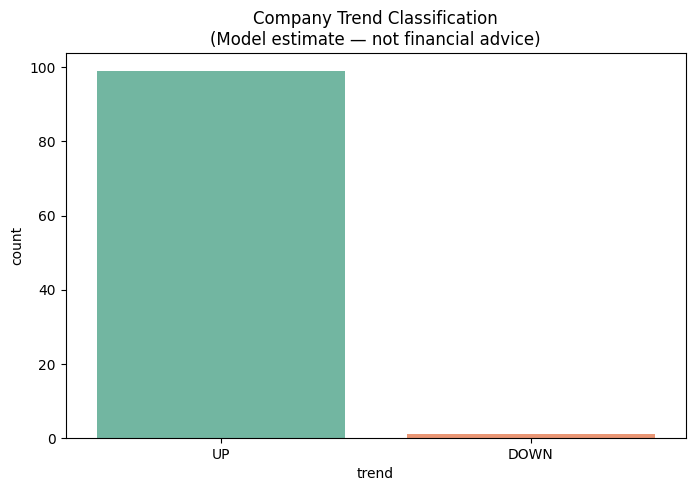

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=trend_df,
    x="trend",
    hue="trend",
    palette="Set2",
    legend=False
)

plt.title(
    "Company Trend Classification\n(Model estimate — not financial advice)"
)

plt.show()

In [12]:
top_20 = (
    profit_loss.groupby("company_id")[
        "sales"
    ]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

In [13]:
forecast_results = []

def forecast_sales(company):

    company_data = profit_loss[
        profit_loss["company_id"] == company
    ]

    company_data = (
        company_data
        .sort_values("year")
    )

    sales_series = company_data["sales"]

    if len(sales_series) < 4:
        return None

    model = ExponentialSmoothing(
        sales_series,
        trend="add",
        seasonal=None
    )

    fitted_model = model.fit()

    forecast = fitted_model.forecast(1)

    next_year = (
        company_data["year"].max() + 1
    )

    forecast_results.append({
        "company_id": company,
        "forecast_year": next_year,
        "forecast_sales": forecast.iloc[0]
    })

    return (
        company_data,
        fitted_model,
        forecast
    )

In [18]:
forecast_results = []

def forecast_sales(company):

    company_data = profit_loss[
        profit_loss["company_id"] == company
    ]

    company_data = (
        company_data
        .sort_values("year")
    )

    sales_series = pd.Series(
        company_data["sales"].values,
        index=pd.to_datetime(
            company_data["year"].astype(str)
        )
    )

    if len(sales_series) < 4:
        return None

    model = ExponentialSmoothing(
        sales_series,
        trend="add",
        seasonal=None
    )

    fitted_model = model.fit()

    forecast = fitted_model.forecast(1)

    next_year = (
        company_data["year"].max() + 1
    )

    forecast_results.append({
        "company_id": company,
        "forecast_year": next_year,
        "forecast_sales": forecast.iloc[0]
    })

    return (
        company_data,
        fitted_model,
        forecast
    )

In [20]:
forecast_results = []

for company in top_20:

    result = forecast_sales(company)

C:\Users\sujit\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\sujit\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\sujit\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\sujit\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\sujit\AppData\Local\Programs\Py

In [21]:
forecast_df = pd.DataFrame(
    forecast_results
)

forecast_df.head()

,company_id,forecast_year,forecast_sales
0,RELIANCE,2025,951288.528648
1,IOC,2025,806488.034974
2,LICI,2025,894917.552123
3,ONGC,2025,605585.556762
4,BPCL,2025,467804.771615


Task was destroyed but it is pending!
task: <Task pending name='Task-135' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\sujit\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-136' coro=<Kernel.shell_main() running at C:\Users\sujit\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\sujit\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\sujit\AppData\Local\Programs\Python\Python313\Lib\site-packages\cycler\__init__.py:442: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  out[k].append(d[k])
Task was destroyed but it is pending!
task: <Task pending name='Task-136' coro=<Kernel.shell_main() running at C:\Users\sujit\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[T

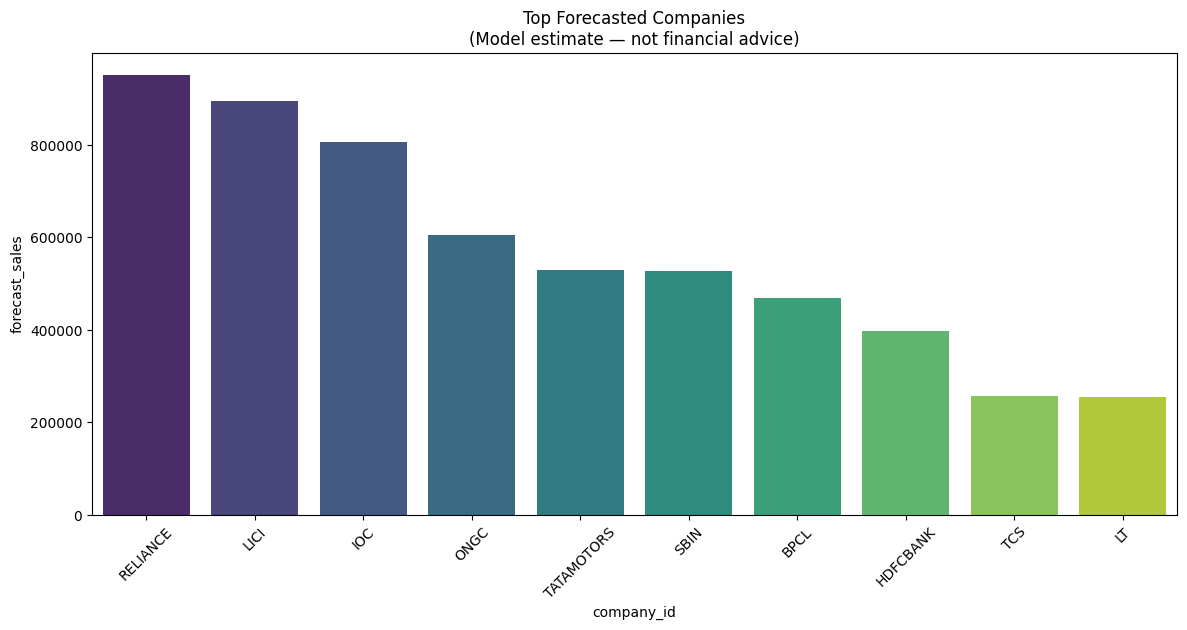

In [22]:
plt.figure(figsize=(14,6))

top_forecasts = (
    forecast_df
    .sort_values(
        "forecast_sales",
        ascending=False
    )
    .head(10)
)

sns.barplot(
    data=top_forecasts,
    x="company_id",
    y="forecast_sales",
    palette="viridis"
)

plt.title(
    "Top Forecasted Companies\n(Model estimate — not financial advice)"
)

plt.xticks(rotation=45)

plt.show()

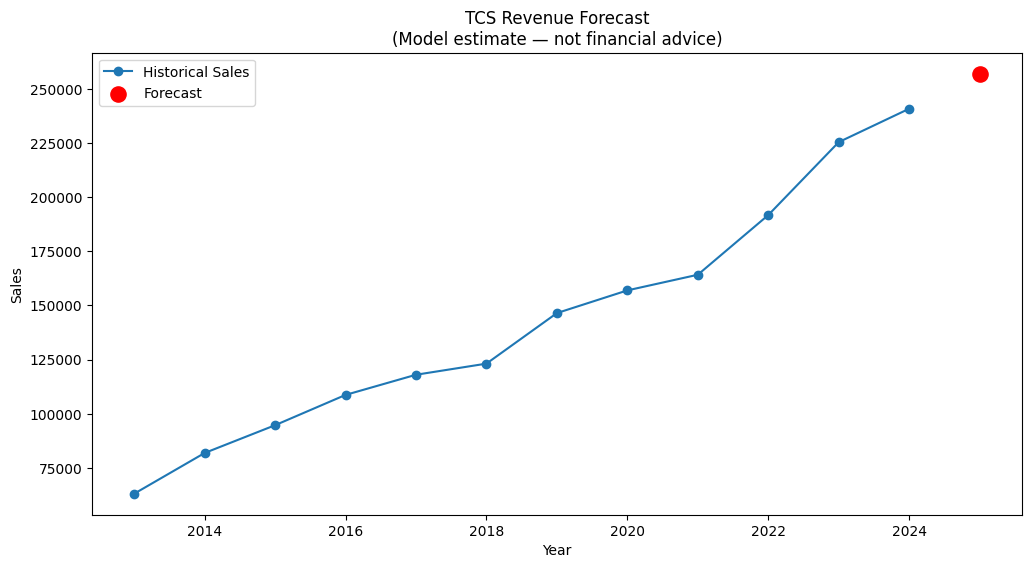

In [23]:
company = "TCS"

company_data = (
    profit_loss[
        profit_loss["company_id"] == company
    ]
    .sort_values("year")
)

forecast_value = (
    forecast_df[
        forecast_df["company_id"] == company
    ]["forecast_sales"].values[0]
)

forecast_year = (
    forecast_df[
        forecast_df["company_id"] == company
    ]["forecast_year"].values[0]
)

plt.figure(figsize=(12,6))

plt.plot(
    company_data["year"],
    company_data["sales"],
    marker="o",
    label="Historical Sales"
)

plt.scatter(
    forecast_year,
    forecast_value,
    color="red",
    s=120,
    label="Forecast"
)

plt.title(
    f"{company} Revenue Forecast\n(Model estimate — not financial advice)"
)

plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [24]:
forecast_df.to_csv(
    "exports/revenue_forecasts.csv",
    index=False
)

trend_df.to_csv(
    "exports/company_trends.csv",
    index=False
)